# Tennis Ball Tracking: Análisis y Visualización

Este notebook analiza el comportamiento de la pelota detectada por `BallDetector` y enriquecida por `BallStats` durante un partido de tenis.

**Columnas clave del CSV:**
- `frame`: número de frame
- `ball_detected` / `interpolated`: si fue detectada o interpolada
- `cx`, `cy`: posición en píxeles (smoothed: `cx_smooth`, `cy_smooth`)
- `mx`, `my`: posición proyectada en metros sobre la cancha
- `dist_meters`: distancia recorrida respecto al frame anterior
- `speed_kmh`: velocidad estimada
- `shot_by`: jugador que realizó el golpe (1.0 o 2.0)
- `conf`: confianza del modelo de detección

| Columna                   | Origen      | Significado                          | Método de Cálculo / Lógica                                                                 |
|---------------------------|-------------|--------------------------------------|--------------------------------------------------------------------------------------------|
| frame                     | Percepción  | Número secuencial del frame.         | Contador del loop de video (cap.read()).                                                   |
| ball_detected             | Percepción  | Booleano: ¿Se detectó la bola?       | True si el modelo de IA encontró un objeto en ese frame.                                   |
| interpolated              | Percepción  | Booleano: ¿Es un dato inventado?     | True si la posición se llenó mediante smooth_ball_positions.                               |
| conf                      | Percepción  | Confianza de la detección.           | Valor 0.0-1.0 devuelto por el modelo de IA.                                                |
| x1, y1, x2, y2            | Percepción  | Bounding box (píxeles).              | Coordenadas de la caja delimitadora en la imagen original.                                 |
| cx, cy                    | Percepción  | Centroide (píxeles).                 | Promedio de las coordenadas de la caja ((x1 + x2) / 2, (y1 + y2) / 2).                     |
| width, height             | Percepción  | Dimensiones de la bola.              | Ancho y alto en píxeles de la detección.                                                   |
| multi_detection           | Percepción  | Flag de ruido.                       | Indica si el modelo vio más de un objeto candidato a pelota.                               |
| shot_by                   | Percepción  | ID del jugador.                      | Calculado por _assign_shot_to_player basado en proximidad.                                 |
| cx_smooth, cy_smooth      | Percepción  | Centroide suavizado.                 | Aplicación de Splines para eliminar el "temblor" de la detección.                          |
| smooth_method             | Percepción  | Tipo de suavizado.                   | Etiqueta que indica si se usó spline o linear.                                             |
| mx                        | Stats       | X en metros.                         | Proyección de cx_smooth a metros usando Homografía.                                        |
| my                        | Stats       | Y en metros.                         | Proyección de cy_smooth a metros usando Homografía.                                        |
| dist_meters               | Stats       | Distancia recorrida.                 | Cálculo euclidiano: √((mx_i - mx_{i-1})² + (my_i - my_{i-1})²).                            |
| speed_kmh                 | Stats       | Velocidad actual.                    | Conversión: distancia × FPS × 3.6 (para pasar de m/s a km/h).                              |

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter
import json
import warnings
warnings.filterwarnings('ignore')

#  Estilo global 
# plt.rcParams.update({
#     'figure.facecolor' : '#0f1117',
#     'axes.facecolor'   : '#1a1d27',
#     'axes.edgecolor'   : '#2e3250',
#     'axes.labelcolor'  : '#c8cfe8',
#     'xtick.color'      : '#7a82a8',
#     'ytick.color'      : '#7a82a8',
#     'text.color'       : '#c8cfe8',
#     'grid.color'       : '#2e3250',
#     'grid.linestyle'   : '--',
#     'grid.alpha'       : 0.5,
#     'font.family'      : 'monospace',
# })

# Paleta de colores
C_BALL    = '#00e5ff'   # cian : trayectoria / pelota
C_P1      = '#ff6b6b'   # rojo : jugador 1
C_P2      = '#ffd93d'   # amarillo: jugador 2
C_INTERP  = '#a855f7'   # púrpura: interpolado
C_DETECT  = '#22c55e'   # verde : detectado

## 1. Carga de datos

In [28]:
CSV_PATH = '../data/tennis_match_1/ball_stats.csv'
JSON_PATH = '../data/tennis_match_1/result.json'

df = pd.read_csv(CSV_PATH)
with open(JSON_PATH, 'r') as f:
    data = json.load(f)

FPS      =   data['video_data']['fps']           # frames por segundo del video original
# Normalizar booleanos (pueden llegar como string)
for col in ['ball_detected', 'interpolated', 'multi_detection']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower().map({'true': True, 'false': False})

# Columna de tiempo
df['time_s'] = df['frame'] / FPS

print(f'Shape : {df.shape}')
print(f'Frames: {df["frame"].min()} -- {df["frame"].max()}')
print(f'Duración estimada: {df["time_s"].max():.1f} s')
df.head()

Shape : (224, 22)
Frames: 1 -- 224
Duración estimada: 7.5 s


,frame,ball_detected,interpolated,conf,x1,y1,x2,y2,cx,cy,...,multi_detection,shot_by,cx_smooth,cy_smooth,smooth_method,mx,my,dist_meters,speed_kmh,time_s
0,1,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,NaN,NaN,NaN,original,NaN,NaN,NaN,NaN,0.033333
1,2,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,NaN,NaN,NaN,original,NaN,NaN,NaN,NaN,0.066667
2,3,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,NaN,NaN,NaN,original,NaN,NaN,NaN,NaN,0.100000
3,4,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,NaN,NaN,NaN,original,NaN,NaN,NaN,NaN,0.133333
4,5,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,NaN,NaN,NaN,original,NaN,NaN,NaN,NaN,0.166667


## 2. Resumen estadístico general

In [29]:
detected    = df['ball_detected'].sum()
interpolated = df['interpolated'].sum()
total       = len(df)
missing     = total - detected - interpolated

speed_valid = df['speed_kmh'].dropna()

print('═' * 50)
print('  RESUMEN GENERAL COMPORTAMIENTO PELOTA')
print('═' * 50)
print(f'  Total frames        : {total}')
print(f'  Detectada           : {detected}  ({100*detected/total:.1f}%)')
print(f'  Interpolada         : {interpolated}  ({100*interpolated/total:.1f}%)')
print(f'  Sin datos           : {missing}  ({100*missing/total:.1f}%)')
print('*' * 50)
print(f'  Velocidad promedio  : {speed_valid.mean():.1f} km/h')
print(f'  Velocidad máxima    : {speed_valid.max():.1f} km/h')
print(f'  Velocidad mediana   : {speed_valid.median():.1f} km/h')
print(f'  Desv. estándar      : {speed_valid.std():.1f} km/h')
print('*' * 50)

for pid in sorted(df['shot_by'].dropna().unique()):
    s = df[df['shot_by'] == pid]['speed_kmh'].dropna()
    label = f'Jugador {int(pid)}'
    print(f'  {label} -- avg: {s.mean():.1f}  max: {s.max():.1f}  golpes: {len(s)}')

print('═' * 50)

══════════════════════════════════════════════════
  RESUMEN GENERAL COMPORTAMIENTO PELOTA
══════════════════════════════════════════════════
  Total frames        : 224
  Detectada           : 115  (51.3%)
  Interpolada         : 75  (33.5%)
  Sin datos           : 34  (15.2%)
**************************************************
  Velocidad promedio  : 47.3 km/h
  Velocidad máxima    : 241.4 km/h
  Velocidad mediana   : 21.4 km/h
  Desv. estándar      : 61.3 km/h
**************************************************
  Jugador 1 -- avg: 51.5  max: 241.4  golpes: 82
  Jugador 2 -- avg: 43.7  max: 225.7  golpes: 97
══════════════════════════════════════════════════


## 3. Detección vs. Interpolación a lo largo del video

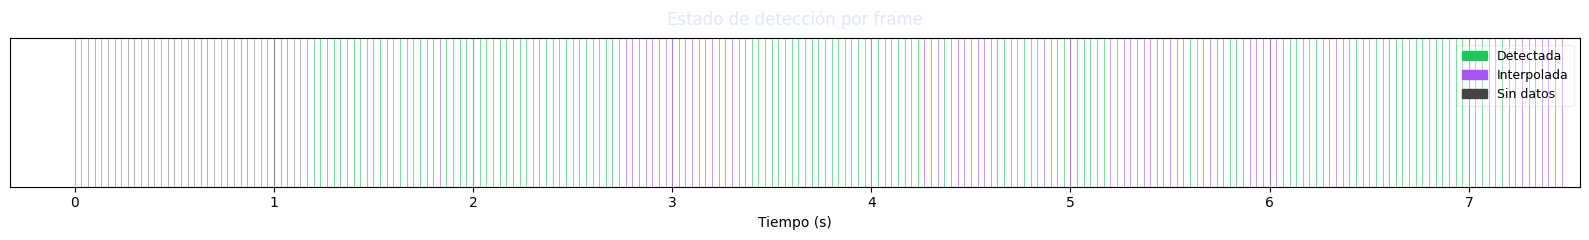

In [30]:
fig, ax = plt.subplots(figsize=(16, 2.5))

for _, row in df.iterrows():
    t = row['time_s']
    if row['ball_detected']:
        ax.axvline(t, color=C_DETECT,  alpha=0.6, lw=0.7)
    elif row['interpolated']:
        ax.axvline(t, color=C_INTERP,  alpha=0.6, lw=0.7)
    else:
        ax.axvline(t, color='#444',     alpha=0.4, lw=0.7)

legend_patches = [
    mpatches.Patch(color=C_DETECT, label='Detectada'),
    mpatches.Patch(color=C_INTERP, label='Interpolada'),
    mpatches.Patch(color='#444',   label='Sin datos'),
]
ax.legend(handles=legend_patches, loc='upper right', framealpha=0.3, fontsize=9)
ax.set_xlabel('Tiempo (s)')
ax.set_title('Estado de detección por frame', pad=10, fontsize=12, color='#e0e6ff')
ax.set_yticks([])
ax.grid(axis='x')
plt.tight_layout()
plt.show()

## 4. Velocidad de la pelota en el tiempo

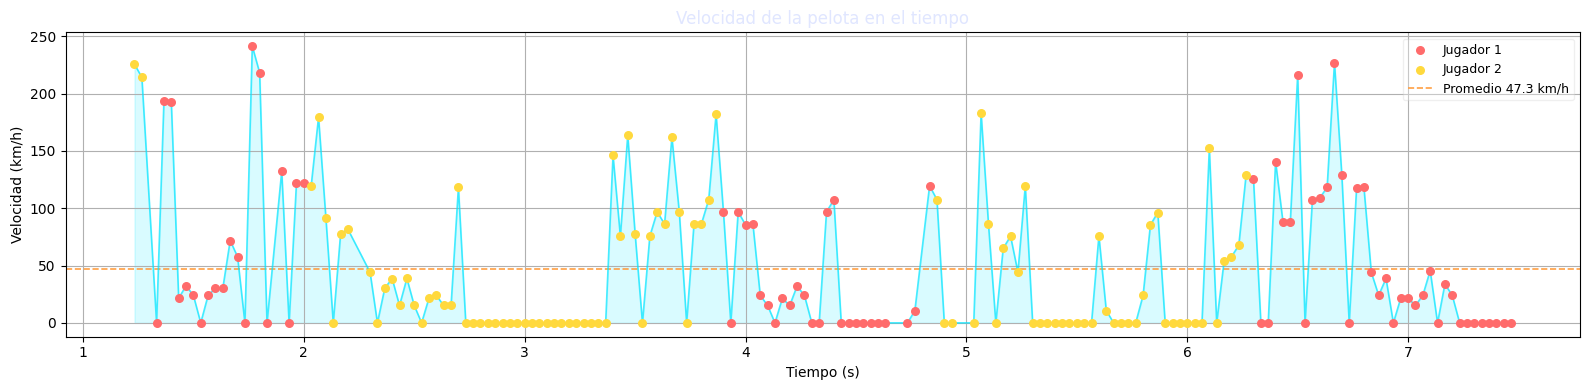

In [31]:
speed_df = df[df['speed_kmh'].notna()].copy()

fig, ax = plt.subplots(figsize=(16, 4))

# Área bajo la curva
ax.fill_between(speed_df['time_s'], speed_df['speed_kmh'],
                alpha=0.15, color=C_BALL)

# Colorear por jugador
for pid, color in [(1.0, C_P1), (2.0, C_P2)]:
    sub = speed_df[speed_df['shot_by'] == pid]
    ax.scatter(sub['time_s'], sub['speed_kmh'],
               color=color, s=30, zorder=4, label=f'Jugador {int(pid)}')

ax.plot(speed_df['time_s'], speed_df['speed_kmh'],
        color=C_BALL, lw=1.2, alpha=0.7, zorder=3)

avg = speed_df['speed_kmh'].mean()
ax.axhline(avg, color='#ff9f43', lw=1.2, ls='--', label=f'Promedio {avg:.1f} km/h')

ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Velocidad (km/h)')
ax.set_title('Velocidad de la pelota en el tiempo', fontsize=12, color='#e0e6ff')
ax.legend(framealpha=0.3, fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

## 5. Distribución de velocidades por jugador

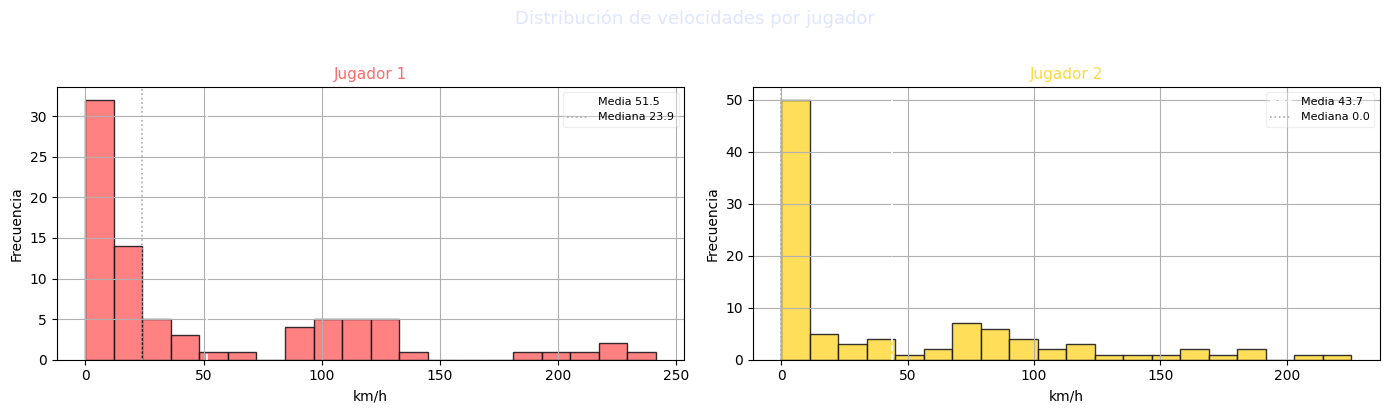

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

players = sorted(df['shot_by'].dropna().unique())
colors  = [C_P1, C_P2]

for ax, pid, col in zip(axes, players, colors):
    data = df[df['shot_by'] == pid]['speed_kmh'].dropna()
    ax.hist(data, bins=20, color=col, edgecolor='#0f1117', alpha=0.85)
    ax.axvline(data.mean(),   color='white', ls='--', lw=1.2, label=f'Media {data.mean():.1f}')
    ax.axvline(data.median(), color='#aaa',  ls=':',  lw=1.2, label=f'Mediana {data.median():.1f}')
    ax.set_title(f'Jugador {int(pid)}', fontsize=11, color=col)
    ax.set_xlabel('km/h')
    ax.set_ylabel('Frecuencia')
    ax.legend(framealpha=0.3, fontsize=8)
    ax.grid(True)

fig.suptitle('Distribución de velocidades por jugador', fontsize=13, color='#e0e6ff', y=1.02)
plt.tight_layout()
plt.show()

## 6. Trayectoria de la pelota en píxeles (cx / cy)

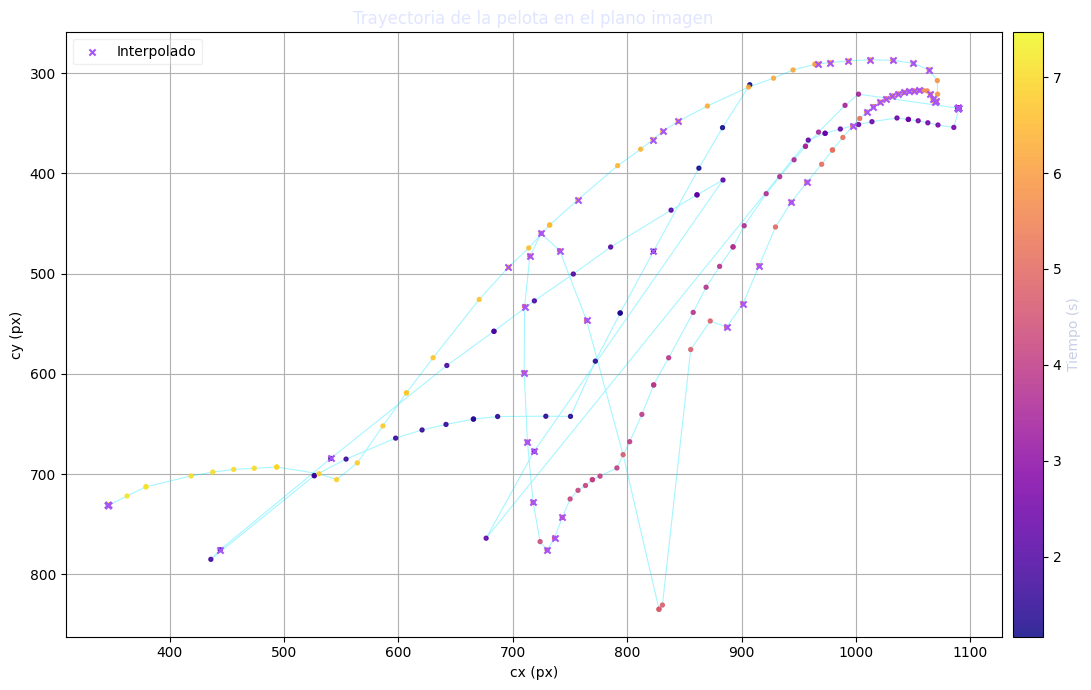

In [33]:
traj = df[df['cx_smooth'].notna()].copy()

fig, ax = plt.subplots(figsize=(12, 7))

# Gradiente temporal
sc = ax.scatter(
    traj['cx_smooth'], traj['cy_smooth'],
    c=traj['time_s'], cmap='plasma', s=8, zorder=3, alpha=0.85
)

# Línea de trayectoria
ax.plot(traj['cx_smooth'], traj['cy_smooth'],
        color=C_BALL, lw=0.8, alpha=0.35, zorder=2)

# Puntos interpolados
interp = traj[traj['interpolated'] == True]
ax.scatter(interp['cx_smooth'], interp['cy_smooth'],
           color=C_INTERP, s=20, marker='x', zorder=4, label='Interpolado')

cbar = plt.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label('Tiempo (s)', color='#c8cfe8')

ax.set_xlabel('cx (px)')
ax.set_ylabel('cy (px)')
ax.invert_yaxis()  # eje Y de imagen invertido
ax.set_title('Trayectoria de la pelota en el plano imagen', fontsize=12, color='#e0e6ff')
ax.legend(framealpha=0.3)
ax.grid(True)
plt.tight_layout()
plt.show()

## 7. Heatmap de posiciones sobre la cancha (mx / my)

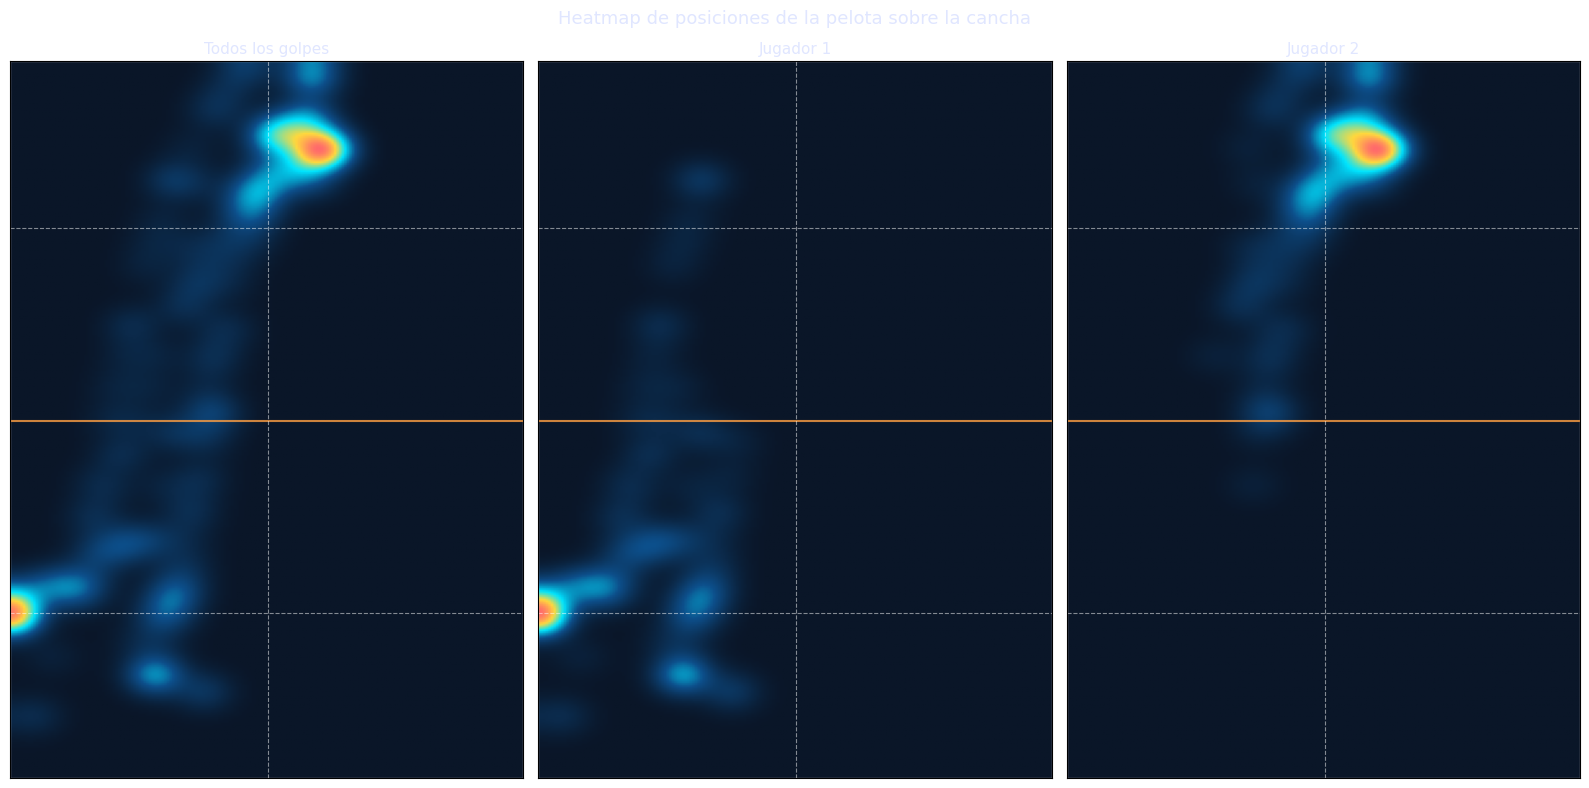

In [34]:
# Dimensiones reales de una cancha de tenis (ITF)
COURT_W = 10.97   # metros (ancho)
COURT_L = 23.77   # metros (largo)

court_df = df[df['mx'].notna() & df['my'].notna()].copy()

#  Construir mapa de calor 
GRID_W, GRID_H = 200, 400
heat = np.zeros((GRID_H, GRID_W), dtype=np.float32)

for mx, my in zip(court_df['mx'], court_df['my']):
    px = int(np.clip(mx / COURT_W * (GRID_W - 1), 0, GRID_W - 1))
    py = int(np.clip(my / COURT_L * (GRID_H - 1), 0, GRID_H - 1))
    heat[py, px] += 1

heat = gaussian_filter(heat, sigma=8)
heat_norm = heat / heat.max() if heat.max() > 0 else heat

#  Colormap personalizado 
cmap_tennis = LinearSegmentedColormap.from_list(
    'tennis', ['#0a1628', '#0d4f8b', '#00e5ff', '#ffd93d', '#ff6b6b']
)

fig, axes = plt.subplots(1, 3, figsize=(16, 8),
                          gridspec_kw={'width_ratios': [1, 1, 1]})

subtitles = ['Todos los golpes', f'Jugador 1', f'Jugador 2']
subsets   = [court_df,
             court_df[court_df['shot_by'] == 1.0],
             court_df[court_df['shot_by'] == 2.0]]

def build_heat(sub):
    h = np.zeros((GRID_H, GRID_W), dtype=np.float32)
    for mx, my in zip(sub['mx'], sub['my']):
        px = int(np.clip(mx / COURT_W * (GRID_W - 1), 0, GRID_W - 1))
        py = int(np.clip(my / COURT_L * (GRID_H - 1), 0, GRID_H - 1))
        h[py, px] += 1
    h = gaussian_filter(h, sigma=8)
    return h / h.max() if h.max() > 0 else h

def draw_court_lines(ax):
    """Dibuja líneas básicas de la cancha sobre el heatmap."""
    lc = 'white'
    lw = 1.0
    a  = 0.5
    # Borde cancha
    ax.plot([0, GRID_W-1], [0, 0],               color=lc, lw=lw, alpha=a)
    ax.plot([0, GRID_W-1], [GRID_H-1, GRID_H-1], color=lc, lw=lw, alpha=a)
    ax.plot([0, 0],         [0, GRID_H-1],        color=lc, lw=lw, alpha=a)
    ax.plot([GRID_W-1, GRID_W-1], [0, GRID_H-1], color=lc, lw=lw, alpha=a)
    # Red (centro)
    mid = GRID_H // 2
    ax.axhline(mid, color='#ff9f43', lw=1.5, alpha=0.8)
    # Línea de servicio (~6.4m desde la red)
    svc_offset = int(6.40 / COURT_L * GRID_H)
    ax.axhline(mid - svc_offset, color=lc, lw=0.8, alpha=a, ls='--')
    ax.axhline(mid + svc_offset, color=lc, lw=0.8, alpha=a, ls='--')
    # Línea central de servicio (vertical)
    ax.axvline(GRID_W // 2, color=lc, lw=0.8, alpha=a, ls='--')

for ax, title, sub in zip(axes, subtitles, subsets):
    h = build_heat(sub)
    ax.imshow(h, cmap=cmap_tennis, origin='upper', aspect='auto',
              extent=[0, GRID_W-1, GRID_H-1, 0])
    draw_court_lines(ax)
    ax.set_title(title, fontsize=11, color='#e0e6ff')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Heatmap de posiciones de la pelota sobre la cancha',
             fontsize=13, color='#e0e6ff')
plt.tight_layout()
plt.show()

## 8. Distancia recorrida acumulada

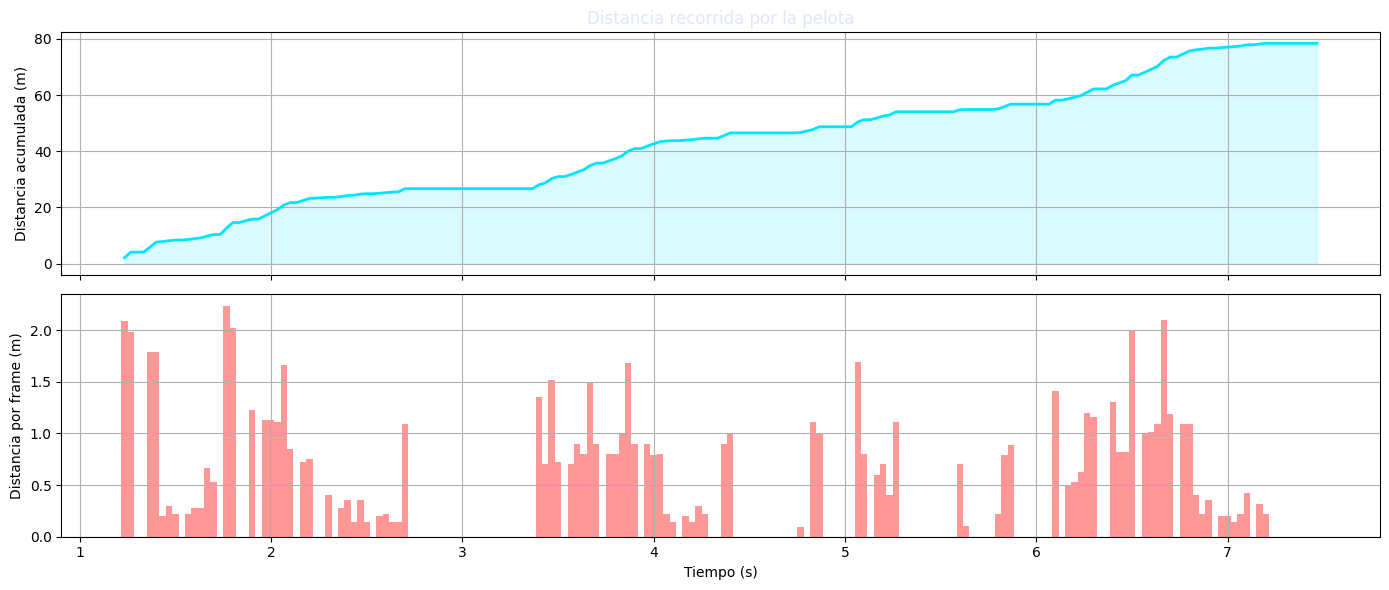

Distancia total recorrida: 78.41 m


In [35]:
dist_df = df[df['dist_meters'].notna()].copy()
dist_df = dist_df.sort_values('frame')
dist_df['dist_acum'] = dist_df['dist_meters'].cumsum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(dist_df['time_s'], dist_df['dist_acum'],
         color=C_BALL, lw=2)
ax1.fill_between(dist_df['time_s'], dist_df['dist_acum'],
                 alpha=0.15, color=C_BALL)
ax1.set_ylabel('Distancia acumulada (m)')
ax1.set_title('Distancia recorrida por la pelota', fontsize=12, color='#e0e6ff')
ax1.grid(True)

ax2.bar(dist_df['time_s'], dist_df['dist_meters'],
        width=1/FPS, color=C_P1, alpha=0.7)
ax2.set_ylabel('Distancia por frame (m)')
ax2.set_xlabel('Tiempo (s)')
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f'Distancia total recorrida: {dist_df["dist_meters"].sum():.2f} m')

## 9. Golpes por jugador y velocidad promedio

 Jugador  Golpes  Vel. Media  Vel. Máx.  Desv. Std
       1      82   51.518659     241.41  64.407652
       2      97   43.747938     225.66  58.693615


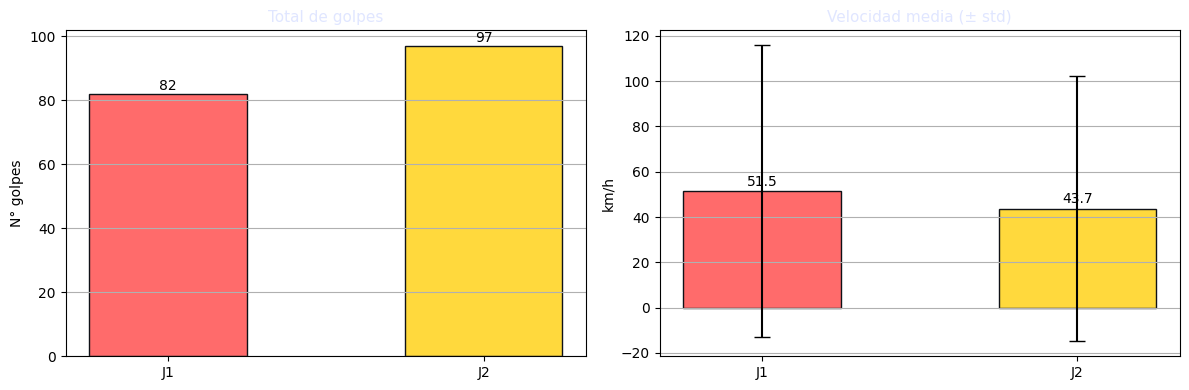

In [36]:
shot_df = df[df['shot_by'].notna() & df['speed_kmh'].notna()].copy()
summary = shot_df.groupby('shot_by')['speed_kmh'].agg(['count', 'mean', 'max', 'std']).reset_index()
summary.columns = ['Jugador', 'Golpes', 'Vel. Media', 'Vel. Máx.', 'Desv. Std']
summary['Jugador'] = summary['Jugador'].astype(int)
print(summary.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

colors_bar = [C_P1, C_P2]

# Golpes totales
ax1.bar([f'J{int(p)}' for p in summary['Jugador']], summary['Golpes'],
        color=colors_bar, edgecolor='#0f1117', width=0.5)
ax1.set_title('Total de golpes', fontsize=11, color='#e0e6ff')
ax1.set_ylabel('N° golpes')
ax1.grid(axis='y')
for bar, v in zip(ax1.patches, summary['Golpes']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(v), ha='center', va='bottom', fontsize=10)

# Velocidad media con barra de error
ax2.bar([f'J{int(p)}' for p in summary['Jugador']], summary['Vel. Media'],
        yerr=summary['Desv. Std'], color=colors_bar, edgecolor='#0f1117',
        width=0.5, capsize=6, error_kw={'color': 'white', 'lw': 1.5})
ax2.set_title('Velocidad media (± std)', fontsize=11, color='#e0e6ff')
ax2.set_ylabel('km/h')
ax2.grid(axis='y')
for bar, v in zip(ax2.patches, summary['Vel. Media']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{v:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 10. Confianza del modelo de detección

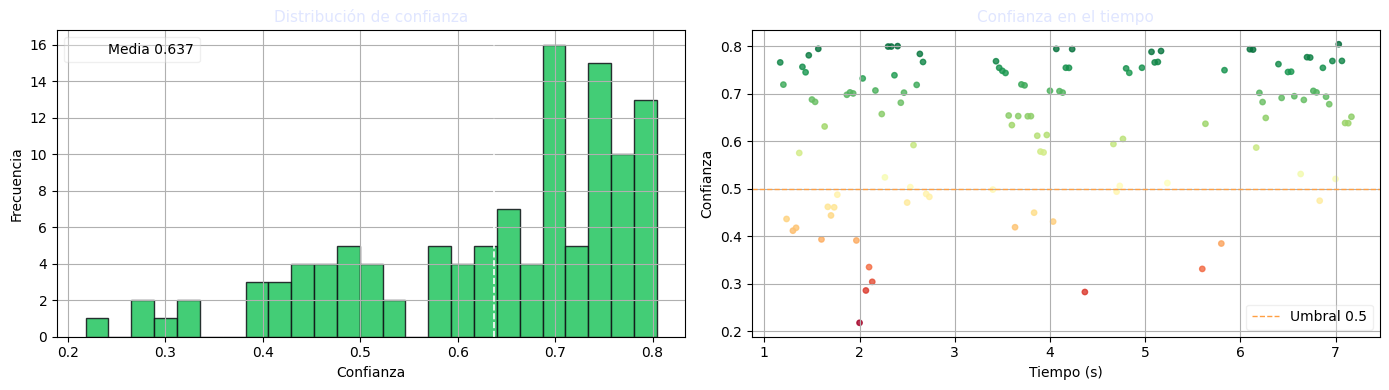

In [37]:
conf_df = df[df['conf'].notna()].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Distribución
ax1.hist(conf_df['conf'], bins=25, color=C_DETECT, edgecolor='#0f1117', alpha=0.85)
ax1.axvline(conf_df['conf'].mean(), color='white', ls='--', lw=1.2,
            label=f'Media {conf_df["conf"].mean():.3f}')
ax1.set_xlabel('Confianza')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribución de confianza', fontsize=11, color='#e0e6ff')
ax1.legend(framealpha=0.3)
ax1.grid(True)

# Confianza en el tiempo
ax2.scatter(conf_df['time_s'], conf_df['conf'],
            c=conf_df['conf'], cmap='RdYlGn', s=15, alpha=0.8)
ax2.axhline(0.5, color='#ff9f43', ls='--', lw=1, label='Umbral 0.5')
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Confianza')
ax2.set_title('Confianza en el tiempo', fontsize=11, color='#e0e6ff')
ax2.legend(framealpha=0.3)
ax2.grid(True)

plt.tight_layout()
plt.show()

## 11. Secuencias de golpes (rallies)

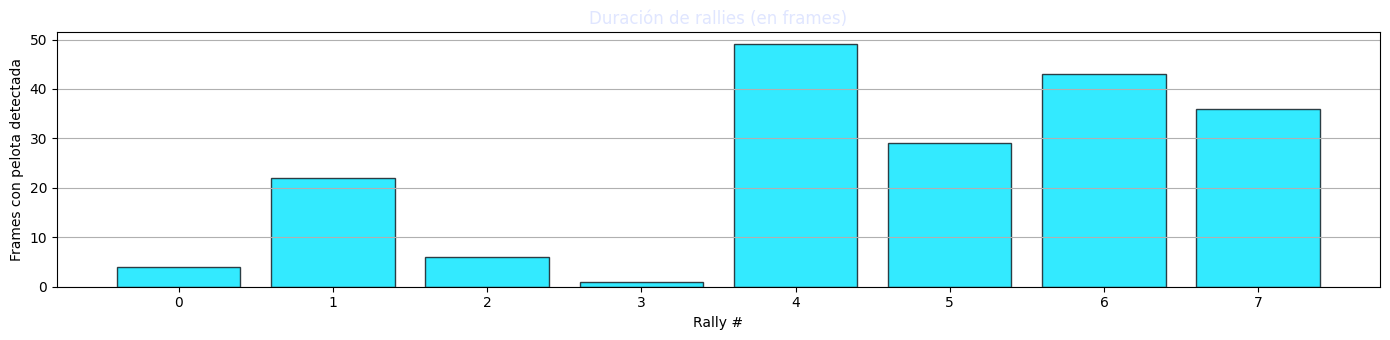

Total rallies    : 8
Rally más largo  : 49 frames (1.63s)
Duración promedio: 23.8 frames (0.79s)


In [38]:
shot_frames = df[df['shot_by'].notna()].copy().sort_values('frame')

# Identificar cambios de jugador como inicio de rally
shot_frames['prev_shot'] = shot_frames['shot_by'].shift(1)
shot_frames['rally_change'] = (
    shot_frames['shot_by'] != shot_frames['prev_shot']
).astype(int)
shot_frames['rally_id'] = shot_frames['rally_change'].cumsum()

rally_counts = shot_frames.groupby('rally_id').size()

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.bar(range(len(rally_counts)), rally_counts.values,
       color=C_BALL, edgecolor='#0f1117', alpha=0.8)
ax.set_xlabel('Rally #')
ax.set_ylabel('Frames con pelota detectada')
ax.set_title('Duración de rallies (en frames)', fontsize=12, color='#e0e6ff')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

print(f'Total rallies    : {len(rally_counts)}')
print(f'Rally más largo  : {rally_counts.max()} frames ({rally_counts.max()/FPS:.2f}s)')
print(f'Duración promedio: {rally_counts.mean():.1f} frames ({rally_counts.mean()/FPS:.2f}s)')

## 12. Dashboard resumen

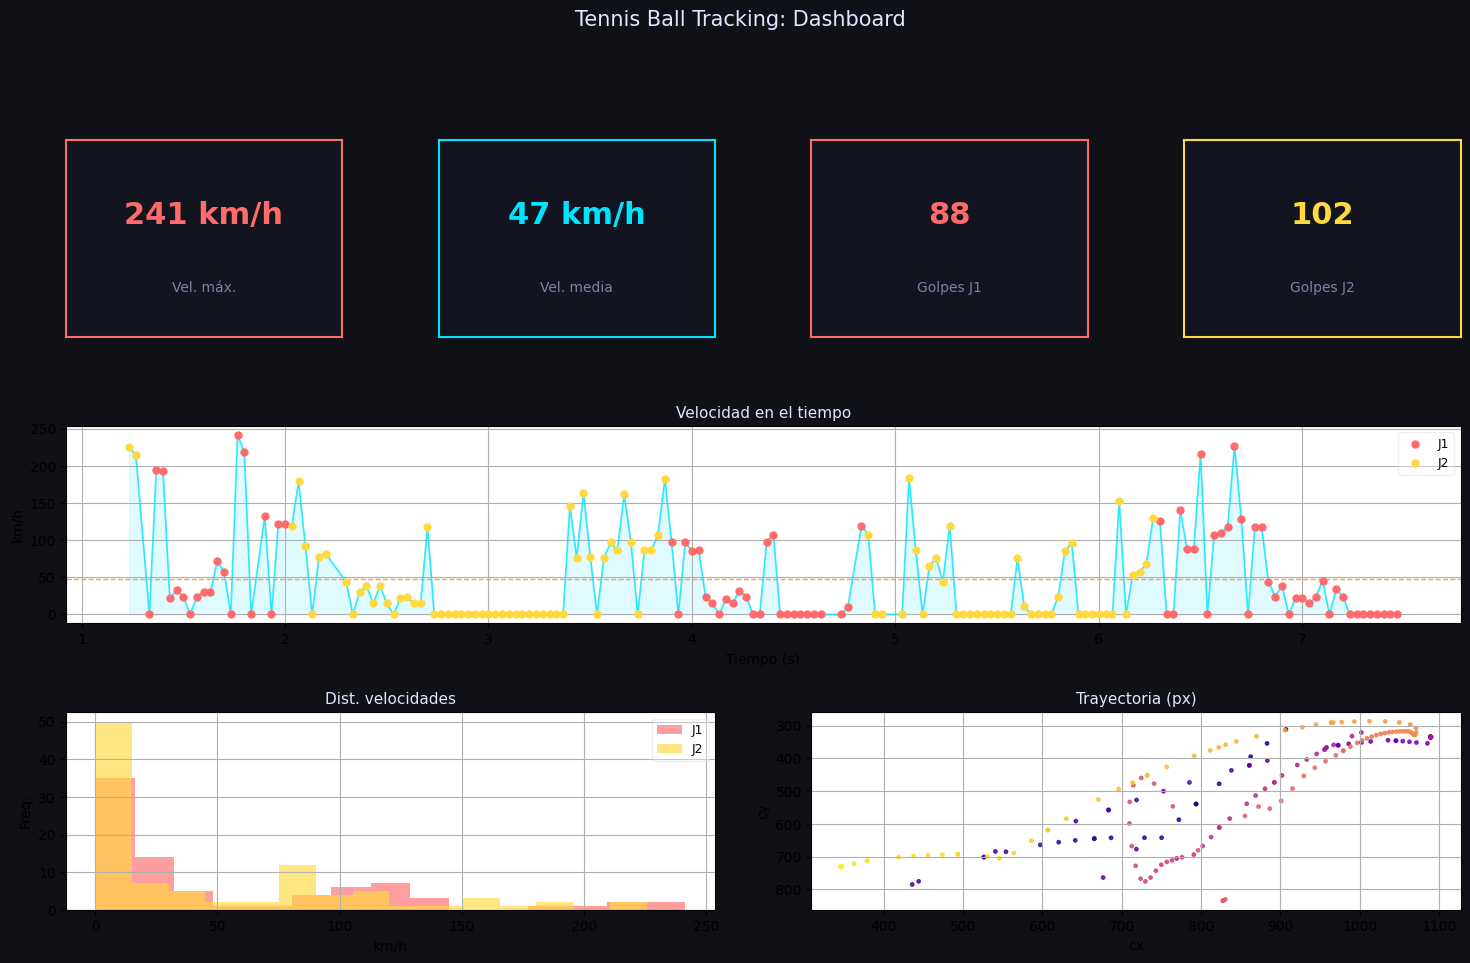

In [39]:
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#0f1117')
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

#  KPI cards 
kpis = [
    ('Vel. máx.',   f"{df['speed_kmh'].max():.0f} km/h",   C_P1),
    ('Vel. media',  f"{df['speed_kmh'].mean():.0f} km/h",  C_BALL),
    ('Golpes J1',   str(int((df['shot_by']==1.0).sum())),   C_P1),
    ('Golpes J2',   str(int((df['shot_by']==2.0).sum())),   C_P2),
]

for i, (label, val, col) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor('#12151f')
    ax.text(0.5, 0.62, val,   ha='center', va='center', fontsize=22,
            color=col, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center', fontsize=10,
            color='#7a82a8', transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(col)
        spine.set_linewidth(1.5)

#  Velocidad en el tiempo 
ax2 = fig.add_subplot(gs[1, :])
sv  = df[df['speed_kmh'].notna()]
ax2.plot(sv['time_s'], sv['speed_kmh'], color=C_BALL, lw=1.2, alpha=0.8)
ax2.fill_between(sv['time_s'], sv['speed_kmh'], alpha=0.12, color=C_BALL)
ax2.axhline(sv['speed_kmh'].mean(), color='#ff9f43', ls='--', lw=1)
for pid, col in [(1.0, C_P1), (2.0, C_P2)]:
    s = sv[sv['shot_by']==pid]
    ax2.scatter(s['time_s'], s['speed_kmh'], color=col, s=25, zorder=4, label=f'J{int(pid)}')
ax2.set_title('Velocidad en el tiempo', fontsize=11, color='#e0e6ff')
ax2.set_xlabel('Tiempo (s)'); ax2.set_ylabel('km/h')
ax2.legend(framealpha=0.3, fontsize=9); ax2.grid(True)

#  Histograma velocidades 
ax3 = fig.add_subplot(gs[2, :2])
for pid, col in [(1.0, C_P1), (2.0, C_P2)]:
    d = df[df['shot_by']==pid]['speed_kmh'].dropna()
    ax3.hist(d, bins=15, color=col, alpha=0.65, label=f'J{int(pid)}')
ax3.set_title('Dist. velocidades', fontsize=11, color='#e0e6ff')
ax3.set_xlabel('km/h'); ax3.set_ylabel('Freq.')
ax3.legend(framealpha=0.3, fontsize=9); ax3.grid(True)

#  Trayectoria 
ax4 = fig.add_subplot(gs[2, 2:])
tr  = df[df['cx_smooth'].notna()]
sc4 = ax4.scatter(tr['cx_smooth'], tr['cy_smooth'],
                  c=tr['time_s'], cmap='plasma', s=6, alpha=0.8)
ax4.invert_yaxis()
ax4.set_title('Trayectoria (px)', fontsize=11, color='#e0e6ff')
ax4.set_xlabel('cx'); ax4.set_ylabel('cy')
ax4.grid(True)

fig.suptitle('Tennis Ball Tracking: Dashboard', fontsize=15,
             color='#e0e6ff', y=1.01)
plt.show()